In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fftpack import fft2, ifft2, fftshift
from tqdm import tqdm

# Set random seed for reproducibility
np.random.seed(42)

def plot_field_2d(data, title, cmap='viridis'):
    """
    Helper function to plot 2D fields.
    """
    plt.figure(figsize=(6, 5))
    plt.imshow(data, cmap=cmap, origin='lower')
    plt.colorbar(label='u(x, y)')
    plt.title(title)
    plt.xlabel('x')
    plt.ylabel('y')
    plt.show()

def get_power_spectrum_2d(data):
    """
    Computes the azimuthally averaged power spectrum.
    Useful for checking if generative models capture the correct frequency content.
    """
    F = fftshift(fft2(data))
    psd = np.abs(F)**2
    return psd

In [ ]:
# --- Plot polish settings (visual only) ---
# This cell only controls figure appearance. It does not change sampling, kernels, spectra, or metrics.
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np

PAPER_DPI = 160
EXPORT_DPI = 300

plt.rcParams.update({
    'figure.dpi': PAPER_DPI,
    'savefig.dpi': EXPORT_DPI,
    'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.03,
    'font.family': 'DejaVu Sans',
    'mathtext.fontset': 'dejavusans',
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'axes.linewidth': 0.9,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'image.interpolation': 'nearest',
})

def polish_axes(ax, *, equal=False, grid=False):
    """Apply consistent visual-only axis styling."""
    if equal:
        ax.set_aspect('equal', adjustable='box')
    ax.tick_params(direction='in', length=3, width=0.8)
    if grid:
        ax.grid(True, alpha=0.22, linestyle='--', linewidth=0.6)
    for spine in ax.spines.values():
        spine.set_linewidth(0.9)
        spine.set_color('0.25')
    return ax

def polish_legend(ax, **kwargs):
    """Draw a compact legend only when labelled artists exist."""
    handles, labels = ax.get_legend_handles_labels()
    labels = [label for label in labels if label and not label.startswith('_')]
    if labels:
        defaults = dict(frameon=True, framealpha=0.92, edgecolor='0.85')
        defaults.update(kwargs)
        return ax.legend(**defaults)
    return None

def set_pi_ticks(ax):
    ticks = [0, np.pi, 2 * np.pi]
    labels = ['0', r'$\pi$', r'$2\pi$']
    ax.set_xticks(ticks)
    ax.set_xticklabels(labels)
    ax.set_yticks(ticks)
    ax.set_yticklabels(labels)
    return ax


## Allen-Cahn Equation (2D)
**Mathematical Form:**
$$ \frac{\partial u}{\partial t} = D \nabla^2 u - \frac{1}{\epsilon^2} u (u^2 - 1) $$

**Characteristics:**
This equation describes phase separation. The solution $u$ tends towards $+1$ or $-1$, forming "grains" separated by sharp interfaces.
*   **Target for GenAI:** Can the model generate sharp interfaces? Can it capture the coarsening rate (how grains grow over time)?

Simulating Allen-Cahn for 300 steps (t=0 to t=0.00)...


100%|██████████| 300/300 [00:00<00:00, 8855.16it/s]



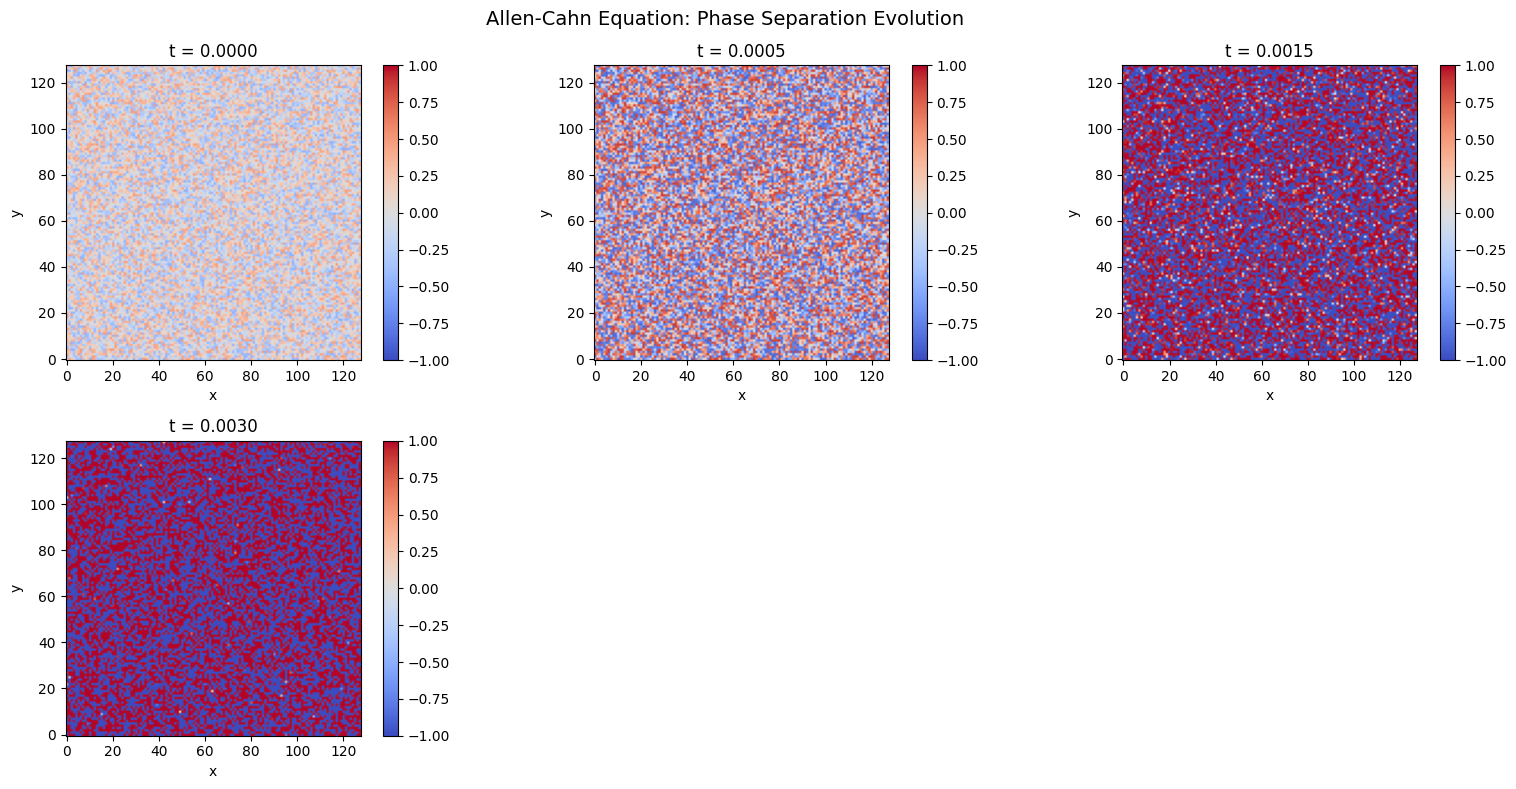

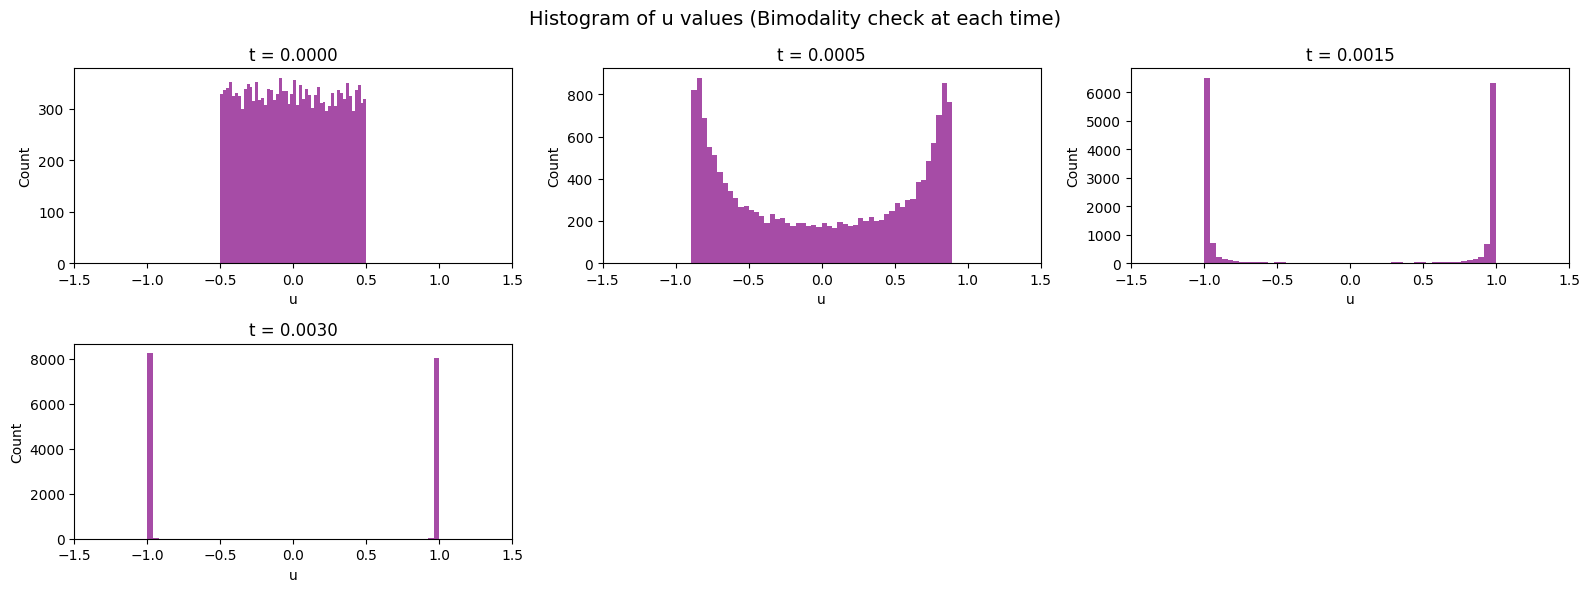

In [2]:
class AllenCahn2D:
    def __init__(self, N=64, L=1.0, D=0.001, epsilon=0.01, dt=0.001):
        """
        N: Grid size (N x N)
        L: Physical domain size
        D: Diffusion coefficient
        epsilon: Interface width parameter
        """
        self.N = N
        self.L = L
        self.D = D
        self.epsilon = epsilon
        self.dt = dt
        self.dx = L / N
        
        # Initialize grid
        self.u = np.random.uniform(-0.5, 0.5, (N, N))
        
    def laplacian(self, u):
        """Finite difference approximation of Laplacian with Periodic BC"""
        u_top = np.roll(u, 1, axis=0)
        u_bottom = np.roll(u, -1, axis=0)
        u_left = np.roll(u, 1, axis=1)
        u_right = np.roll(u, -1, axis=1)
        return (u_top + u_bottom + u_left + u_right - 4*u) / (self.dx**2)

    def step(self):
        """Explicit Euler time stepping"""
        # Reaction term: -1/eps^2 * u * (u^2 - 1)
        reaction = -(1.0 / self.epsilon**2) * self.u * (self.u**2 - 1.0)
        diffusion = self.D * self.laplacian(self.u)
        
        self.u += self.dt * (diffusion + reaction)

# --- Simulation with snapshots at multiple time points ---
# epsilon controls reaction speed: smaller epsilon = faster reaction
# Reaction term is -1/eps^2 * u*(u^2-1), so eps=0.02 is 25x faster than eps=0.1
ac_sim = AllenCahn2D(N=128, dt=1e-5, epsilon=0.02)

# Define time points to capture
# With smaller epsilon (0.02), reaction is faster so we use shorter times
snapshot_times = np.array([0, 0.0005, 0.0015, 0.003])
snapshot_steps = set([int(t / ac_sim.dt) for t in snapshot_times])  # Use set for faster lookup
total_steps = max(snapshot_steps)  # Only simulate as long as needed

snapshots = {}

# Save initial state (t=0)
snapshots[0] = ac_sim.u.copy()

print(f"Simulating Allen-Cahn for {total_steps} steps (t=0 to t={total_steps*ac_sim.dt:.2f})...")
for step in tqdm(range(1, total_steps + 1)):
    ac_sim.step()
    if step in snapshot_steps:
        snapshots[step] = ac_sim.u.copy()

# --- Visualization: Multiple time snapshots ---
n_snapshots = len(snapshot_times)
n_cols = 3
n_rows = (n_snapshots + n_cols - 1) // n_cols  # Ceiling division

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows))
axes = axes.flatten()

for idx, t_phys in enumerate(snapshot_times):
    step_num = int(t_phys / ac_sim.dt)
    ax = axes[idx]
    im = ax.imshow(snapshots[step_num], cmap='coolwarm', origin='lower', vmin=-1, vmax=1, interpolation='nearest')
    ax.set_title(f't = {t_phys:.4f}', fontsize=12)
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.02)

# Hide unused subplots
for idx in range(n_snapshots, len(axes)):
    axes[idx].axis('off')

plt.suptitle('Allen-Cahn Equation: Phase Separation Evolution', fontsize=14)
plt.tight_layout(pad=1.1)
plt.show()

# --- Histogram visualization for each time snapshot ---
fig2, axes2 = plt.subplots(n_rows, n_cols, figsize=(16, 3 * n_rows))
axes2 = axes2.flatten()

for idx, t_phys in enumerate(snapshot_times):
    step_num = int(t_phys / ac_sim.dt)
    ax = axes2[idx]
    ax.hist(snapshots[step_num].flatten(), bins=50, density=True, color='purple', alpha=0.65, edgecolor='none')
    ax.set_title(f't = {t_phys:.4f}', fontsize=12)
    ax.set_xlabel('u')
    ax.set_ylabel('Density')
    ax.set_xlim(-1.5, 1.5)

# Hide unused subplots
for idx in range(n_snapshots, len(axes2)):
    axes2[idx].axis('off')

plt.suptitle('Histogram of u values (Bimodality check at each time)', fontsize=14)

plt.tight_layout(pad=1.1)
plt.show()

## KSWGD Analysis: Learning the Distribution at Different Time Steps

We will use the **KSWGD (Koopman Spectral Wasserstein Gradient Descent)** method to:
1. Learn the distribution of spatial patterns at each time snapshot
2. Generate new samples from the learned distribution
3. Observe if the generated distribution captures the **bimodal structure** (δ-like peaks at ±1)

**Pipeline:**
- Each snapshot is a 128×128 = 16384-dimensional vector
- Use Autoencoder to reduce to a low-dimensional latent space
- Apply EDMD + KSWGD in latent space
- Decode back and visualize the distribution

In [3]:
# === Setup for KSWGD ===
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import pairwise_distances
from sklearn.preprocessing import PolynomialFeatures
from scipy.linalg import eig
from tqdm.auto import trange
import warnings
warnings.filterwarnings("ignore")

# Import KSWGD kernel functions
from grad_ker1 import grad_ker1
from K_tar_eval import K_tar_eval

# Try to import GPU versions
try:
    import cupy as cp
    from grad_ker1_gpu import grad_ker1 as grad_ker1_gpu
    from K_tar_eval_gpu import K_tar_eval as K_tar_eval_gpu
    KSWGD_GPU_AVAILABLE = True
except Exception:
    cp = None
    grad_ker1_gpu = None
    K_tar_eval_gpu = None
    KSWGD_GPU_AVAILABLE = False

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
use_gpu_kswgd = bool(KSWGD_GPU_AVAILABLE and torch.cuda.is_available())

print(f"Using device: {device}")
print(f"KSWGD GPU backend: {'enabled' if use_gpu_kswgd else 'disabled'}")

Using device: cuda
KSWGD GPU backend: enabled


/workspace/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
# === Autoencoder for Allen-Cahn spatial patterns ===
# Input: 128x128 = 16384 dimensional vectors
# Latent: 8-16 dimensions (tunable)

class ACEncoder(nn.Module):
    """Encoder for Allen-Cahn 2D fields"""
    def __init__(self, input_size=128, latent_dim=8):
        super().__init__()
        self.input_size = input_size
        flat_size = input_size * input_size
        
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(flat_size, 512),
            nn.ReLU(),
            nn.Linear(512, 128),
            nn.ReLU(),
            nn.Linear(128, latent_dim),
        )
    
    def forward(self, x):
        return self.net(x)

class ACDecoder(nn.Module):
    """Decoder for Allen-Cahn 2D fields"""
    def __init__(self, input_size=128, latent_dim=8):
        super().__init__()
        self.input_size = input_size
        flat_size = input_size * input_size
        
        self.net = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 512),
            nn.ReLU(),
            nn.Linear(512, flat_size),
            nn.Tanh(),  # Output in [-1, 1] range for Allen-Cahn
        )
    
    def forward(self, z):
        x_flat = self.net(z)
        return x_flat.view(-1, self.input_size, self.input_size)

class ACAutoencoder(nn.Module):
    """Autoencoder for Allen-Cahn 2D fields"""
    def __init__(self, input_size=128, latent_dim=8):
        super().__init__()
        self.encoder = ACEncoder(input_size, latent_dim)
        self.decoder = ACDecoder(input_size, latent_dim)
        self.latent_dim = latent_dim
    
    def forward(self, x):
        z = self.encoder(x)
        x_recon = self.decoder(z)
        return x_recon, z

print("Autoencoder architecture defined.")

Autoencoder architecture defined.


In [5]:
# === KSWGD Function for Allen-Cahn ===
# 
# TRUE TIME EVOLUTION VERSION:
# 1. Generate time series data: t=0, t=dt, t=2dt, ...
# 2. Use ONLY t=0 → t=dt pairs to build Koopman operator
# 3. Use Koopman to PREDICT distributions at future times
# 4. Compare predictions with ground truth

def generate_ac_time_series_ensemble(n_samples=200, N=128, dt_sim=1e-4, epsilon=0.1, 
                                      time_points=[0, 0.02, 0.05, 0.1], verbose=True):
    """
    Generate an ensemble of Allen-Cahn time series from different initial conditions.
    Each simulation is saved at multiple time points.
    
    Args:
        n_samples: Number of independent simulations
        N: Grid size
        dt_sim: Simulation time step
        epsilon: Interface width parameter
        time_points: List of times to save snapshots
        
    Returns:
        dict: {time: np.array of shape (n_samples, N, N)} for each time point
    """
    if verbose:
        print(f"  Generating {n_samples} independent AC time series...")
        print(f"  Time points: {time_points}")
    
    # Convert time points to step numbers
    time_steps = {t: int(t / dt_sim) for t in time_points}
    max_steps = max(time_steps.values())
    
    # Initialize output dictionary
    ensemble = {t: [] for t in time_points}
    
    for i in tqdm(range(n_samples), desc="Ensemble generation", disable=not verbose):
        # Create new simulation with fresh random IC
        ac = AllenCahn2D(N=N, dt=dt_sim, epsilon=epsilon)
        ac.u = np.random.uniform(-0.5, 0.5, (N, N))
        
        current_step = 0
        
        # Save t=0 if needed
        if 0 in time_steps.values():
            for t, step in time_steps.items():
                if step == 0:
                    ensemble[t].append(ac.u.copy())
        
        # Evolve and save at target times
        for step in range(1, max_steps + 1):
            ac.step()
            current_step = step
            
            # Check if we need to save at this step
            for t, target_step in time_steps.items():
                if step == target_step and target_step > 0:
                    ensemble[t].append(ac.u.copy())
    
    # Convert to numpy arrays
    ensemble = {t: np.array(snapshots) for t, snapshots in ensemble.items()}
    
    if verbose:
        for t, data in ensemble.items():
            print(f"    t={t}: shape {data.shape}")
    
    return ensemble


def train_autoencoder_on_data(data_flat, N, latent_dim, n_epochs, verbose=True):
    """Train autoencoder on flattened data."""
    # Scale to [-1, 1]
    data_min = data_flat.min()
    data_max = data_flat.max()
    data_range = data_max - data_min + 1e-8
    data_scaled = 2.0 * (data_flat - data_min) / data_range - 1.0
    
    train_tensor = torch.FloatTensor(data_scaled).to(device)
    train_loader = DataLoader(TensorDataset(train_tensor), batch_size=32, shuffle=True)
    
    ae = ACAutoencoder(input_size=N, latent_dim=latent_dim).to(device)
    optimizer = optim.Adam(ae.parameters(), lr=1e-3)
    
    for epoch in range(n_epochs):
        total_loss = 0
        for (batch,) in train_loader:
            batch = batch.view(-1, N, N)
            optimizer.zero_grad()
            recon, z = ae(batch)
            loss = nn.MSELoss()(recon, batch)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        
        if verbose and (epoch + 1) % 25 == 0:
            print(f"    Epoch {epoch+1}/{n_epochs}, Loss: {total_loss/len(train_loader):.6f}")
    
    return ae, data_min, data_max


def run_kswgd_time_evolution(time_series_ensemble, latent_dim=8, poly_order=5,
                              m_particles=100, num_iters_kswgd=500, step_size_kswgd=0.1,
                              n_epochs_ae=100, verbose=True):
    """
    Run KSWGD with TRUE TIME EVOLUTION using Koopman operator.
    
    KEY DIFFERENCE from previous version:
    - Koopman operator is built from t=0 → t=dt data ONLY
    - Future time distributions are PREDICTED using repeated Koopman applications
    - We compare predictions vs ground truth at each future time
    
    Args:
        time_series_ensemble: dict {time: (n_samples, N, N)} from generate_ac_time_series_ensemble
        
    Returns:
        dict with predictions and ground truth at each time
    """
    time_points = sorted(time_series_ensemble.keys())
    if len(time_points) < 2:
        raise ValueError("Need at least 2 time points for time evolution")
    
    t0 = time_points[0]  # Initial time (usually 0)
    t1 = time_points[1]  # First time step (for building Koopman)
    dt_koopman = t1 - t0  # Time step for Koopman operator
    
    data_t0 = time_series_ensemble[t0]
    data_t1 = time_series_ensemble[t1]
    n_samples, N, _ = data_t0.shape
    
    if verbose:
        print(f"\n  === TRUE KOOPMAN TIME EVOLUTION ===")
        print(f"  Building Koopman from t={t0} → t={t1} (dt={dt_koopman})")
        print(f"  Will PREDICT distributions at t={time_points[2:]} using this operator")
        print(f"  Ensemble size: {n_samples}")
    
    # ============================================================
    # Step 1: Train Autoencoder on ALL time point data (for fair encoding)
    # ============================================================
    if verbose:
        print(f"\n  Training Autoencoder on all time data...")
    
    all_data = np.concatenate([time_series_ensemble[t] for t in time_points], axis=0)
    all_data_flat = all_data.reshape(-1, N*N)
    
    ae, data_min, data_max = train_autoencoder_on_data(
        all_data_flat, N, latent_dim, n_epochs_ae, verbose
    )
    data_range = data_max - data_min + 1e-8
    
    # ============================================================
    # Step 2: Encode t=0 and t=dt data to latent space
    # ============================================================
    ae.eval()
    
    def encode_data(data_3d):
        data_flat = data_3d.reshape(-1, N*N)
        data_scaled = 2.0 * (data_flat - data_min) / data_range - 1.0
        with torch.no_grad():
            tensor = torch.FloatTensor(data_scaled).to(device).view(-1, N, N)
            z = ae.encoder(tensor).cpu().numpy()
        return z.astype(np.float64)
    
    Z_t0 = encode_data(data_t0)  # Latent codes at t=0
    Z_t1 = encode_data(data_t1)  # Latent codes at t=dt
    
    if verbose:
        print(f"  Latent codes: Z_t0 {Z_t0.shape}, Z_t1 {Z_t1.shape}")
    
    # ============================================================
    # Step 3: Build EDMD Koopman Operator from (t0, t1) pairs
    # This is the KEY: we use PAIRED data (same IC at different times)
    # ============================================================
    if verbose:
        print(f"\n  Building EDMD Koopman operator (poly_order={poly_order})...")
    
    poly = PolynomialFeatures(degree=poly_order, include_bias=True)
    Phi_X = poly.fit_transform(Z_t0)  # Features at t=0
    Phi_Y = poly.transform(Z_t1)       # Features at t=dt
    n_features = Phi_X.shape[1]
    
    if verbose:
        print(f"    Polynomial features: {n_features}")
    
    # EDMD: K such that Phi_Y ≈ Phi_X @ K
    reg_edmd = 1e-4
    G_edmd = (Phi_X.T @ Phi_X) / n_samples + reg_edmd * np.eye(n_features)
    A_edmd = (Phi_X.T @ Phi_Y) / n_samples
    K_edmd = np.linalg.solve(G_edmd, A_edmd)  # Koopman operator in feature space
    
    if verbose:
        print(f"    Koopman operator K shape: {K_edmd.shape}")
    
    # ============================================================
    # Step 4: Build KSWGD operators from t=0 data (target distribution)
    # ============================================================
    if verbose:
        print(f"\n  Building KSWGD operators from t=0 distribution...")
    
    Z_tar = Z_t0
    sq_tar = np.sum(Z_tar ** 2, axis=1)
    
    kswgd_dists = pairwise_distances(Z_tar, metric="euclidean")
    eps_kswgd = np.median(kswgd_dists**2) / (2.0 * np.log(Z_tar.shape[0] + 1))
    eps_kswgd = float(max(eps_kswgd, 1e-6))
    
    data_kernel = np.exp(-kswgd_dists**2 / (2.0 * eps_kswgd))
    p_x = np.sqrt(np.sum(data_kernel, axis=1))
    data_kernel_norm = data_kernel / (p_x[:, None] * p_x[None, :] + 1e-12)
    
    D_y = np.sum(data_kernel_norm, axis=0)
    rw_kernel = 0.5 * (data_kernel_norm / (D_y + 1e-12) + data_kernel_norm / (D_y[:, None] + 1e-12))
    rw_kernel = np.nan_to_num(rw_kernel)
    
    lambda_ns_kernel, phi_kernel = np.linalg.eigh(rw_kernel)
    phi_kernel = np.real(phi_kernel[:, ::-1])
    lambda_ns_kernel = np.real(lambda_ns_kernel[::-1])
    
    tol_kswgd = 1e-6
    mask_kswgd = lambda_ns_kernel >= tol_kswgd
    above_tol = int(np.sum(mask_kswgd))
    phi_trunc_kswgd = phi_kernel[:, :above_tol]
    
    lambda_gen_kernel = lambda_ns_kernel - 1.0
    inv_lambda = np.zeros_like(lambda_gen_kernel)
    inv_lambda[1:] = 1.0 / np.clip(np.abs(lambda_gen_kernel[1:]), 1e-12, None)
    inv_lambda *= eps_kswgd
    
    lambda_ns_inv = np.zeros_like(lambda_ns_kernel)
    lambda_ns_inv[mask_kswgd] = eps_kswgd / (lambda_ns_kernel[mask_kswgd] + 1e-3)
    lambda_ns_s_ns_kswgd = (lambda_ns_inv * inv_lambda * lambda_ns_inv)[:above_tol]
    
    p_tar = np.sum(data_kernel, axis=0)
    sqrt_p = np.sqrt(p_tar + 1e-12)
    D_vec = np.sum(data_kernel / sqrt_p[:, None] / sqrt_p[None, :], axis=1)
    
    if verbose:
        print(f"    Using {above_tol} kernel eigenfunctions")
    
    # ============================================================
    # Step 5: KSWGD to sample from t=0 distribution
    # ============================================================
    if verbose:
        print(f"\n  Running KSWGD to sample t=0 distribution...")
    
    rng_kswgd = np.random.default_rng(42)
    grad_fn = grad_ker1_gpu if use_gpu_kswgd else grad_ker1
    K_eval_fn = K_tar_eval_gpu if use_gpu_kswgd else K_tar_eval
    xp = cp if use_gpu_kswgd else np
    
    # Initialize from scaled Gaussian
    z_std = np.std(Z_t0, axis=0)
    z_mean = np.mean(Z_t0, axis=0)
    init_particles = rng_kswgd.normal(0.0, 1.0, size=(m_particles, latent_dim)) * z_std + z_mean
    
    if use_gpu_kswgd:
        Z_tar_dev = cp.asarray(Z_tar)
        p_tar_dev = cp.asarray(p_tar)
        sq_tar_dev = cp.asarray(sq_tar)
        D_vec_dev = cp.asarray(D_vec)
        phi_trunc_dev = cp.asarray(phi_trunc_kswgd)
        lambda_ns_s_ns_dev = cp.asarray(lambda_ns_s_ns_kswgd)
        z_hist = cp.zeros((m_particles, latent_dim, num_iters_kswgd), dtype=cp.float64)
        z_hist[:, :, 0] = cp.asarray(init_particles, dtype=cp.float64)
    else:
        Z_tar_dev = Z_tar
        p_tar_dev = p_tar
        sq_tar_dev = sq_tar
        D_vec_dev = D_vec
        phi_trunc_dev = phi_trunc_kswgd
        lambda_ns_s_ns_dev = lambda_ns_s_ns_kswgd
        z_hist = np.zeros((m_particles, latent_dim, num_iters_kswgd), dtype=np.float64)
        z_hist[:, :, 0] = init_particles
    
    for t in range(num_iters_kswgd - 1):
        grad_matrix = grad_fn(z_hist[:, :, t], Z_tar_dev, p_tar_dev, sq_tar_dev, D_vec_dev, eps_kswgd)
        cross_matrix = K_eval_fn(Z_tar_dev, z_hist[:, :, t], p_tar_dev, sq_tar_dev, D_vec_dev, eps_kswgd)
        
        tmp = phi_trunc_dev.T @ cross_matrix
        tmp = lambda_ns_s_ns_dev[:, None] * tmp
        kswgd_push = phi_trunc_dev @ tmp
        
        for d in range(latent_dim):
            sum_term = grad_matrix[:, :, d] @ kswgd_push
            z_hist[:, d, t + 1] = z_hist[:, d, t] - (step_size_kswgd / m_particles) * xp.sum(sum_term, axis=1)
    
    # Particles at t=0 (from KSWGD)
    if use_gpu_kswgd:
        Z_particles_t0 = cp.asnumpy(z_hist[:, :, -1])
    else:
        Z_particles_t0 = z_hist[:, :, -1]
    
    if verbose:
        print(f"    Generated {m_particles} particles at t=0")
    
    # ============================================================
    # Step 6: Use Koopman to PREDICT future time distributions
    # ============================================================
    if verbose:
        print(f"\n  === KOOPMAN TIME EVOLUTION ===")
        print(f"  Predicting future distributions using Koopman operator...")
    
    results = {}
    
    # Store t=0 results
    results[t0] = {
        'predicted_latent': Z_particles_t0,
        'ground_truth_latent': Z_t0,
    }
    
    # Current particles in latent space
    Z_current = Z_particles_t0.copy()
    
    for i, t_target in enumerate(time_points[1:], 1):
        # Number of Koopman steps needed
        n_koopman_steps = i  # t1 needs 1 step, t2 needs 2 steps, etc.
        
        if verbose:
            print(f"\n    t = {t_target}: applying Koopman {n_koopman_steps} time(s)")
        
        # Apply Koopman operator n_koopman_steps times starting from t=0
        Z_pred = Z_particles_t0.copy()
        for step in range(n_koopman_steps):
            # Transform to feature space
            Phi_pred = poly.transform(Z_pred)
            # Apply Koopman
            Phi_next = Phi_pred @ K_edmd
            # Extract latent coordinates (first latent_dim features after bias)
            # Note: PolynomialFeatures with include_bias=True puts bias first,
            # then degree-1 terms (which are the original coordinates)
            Z_pred = Phi_next[:, 1:latent_dim+1]
        
        # Get ground truth at this time
        Z_gt = encode_data(time_series_ensemble[t_target])
        
        results[t_target] = {
            'predicted_latent': Z_pred,
            'ground_truth_latent': Z_gt,
            'n_koopman_steps': n_koopman_steps,
        }
        
        if verbose:
            print(f"      Predicted latent mean: {Z_pred.mean(axis=0)[:3]}...")
            print(f"      Ground truth mean:     {Z_gt.mean(axis=0)[:3]}...")
    
    # ============================================================
    # Step 7: Decode all predictions and ground truths
    # ============================================================
    if verbose:
        print(f"\n  Decoding predictions to original space...")
    
    def decode_latent(z_latent):
        with torch.no_grad():
            z_tensor = torch.FloatTensor(z_latent).to(device)
            decoded = ae.decoder(z_tensor).cpu().numpy()
        # Rescale back
        samples = (decoded.reshape(-1, N*N) + 1.0) / 2.0 * data_range + data_min
        return samples.reshape(-1, N, N)
    
    for t in time_points:
        results[t]['predicted_samples'] = decode_latent(results[t]['predicted_latent'])
        results[t]['ground_truth_samples'] = time_series_ensemble[t]
    
    results['meta'] = {
        'time_points': time_points,
        'dt_koopman': dt_koopman,
        'ae': ae,
        'K_edmd': K_edmd,
        'poly': poly,
    }
    
    if verbose:
        print(f"\n  Time evolution complete!")
    
    return results

print("KSWGD functions defined (TRUE TIME EVOLUTION version).")
print("\nKey difference from previous version:")
print("  - Koopman operator is built from t=0 → t=dt data ONLY")
print("  - Future distributions are PREDICTED (not fitted)")
print("  - This tests Koopman's predictive ability!")

KSWGD functions defined (TRUE TIME EVOLUTION version).

Key difference from previous version:
  - Koopman operator is built from t=0 → t=dt data ONLY
  - Future distributions are PREDICTED (not fitted)
  - This tests Koopman's predictive ability!


In [6]:
# === Run TRUE TIME EVOLUTION with Koopman Operator ===
#
# This version:
# 1. Builds Koopman operator from t=0 → t=dt pairs ONLY
# 2. Uses Koopman to PREDICT future distributions
# 3. Compares predictions with ground truth

# Define time points (matching snapshot_times in Cell 3: 0 to 0.003)
# t=0 is initial, t=0.0005 is used to build Koopman, t=0.0015 and t=0.003 are PREDICTED
time_points = [0, 0.0005, 0.0015, 0.003]

print("="*70)
print("TRUE KOOPMAN TIME EVOLUTION for Allen-Cahn")
print("="*70)
print(f"\nTime points: {time_points}")
print(f"  - t={time_points[0]} → t={time_points[1]}: Used to BUILD Koopman operator")
print(f"  - t={time_points[2:]}: PREDICTED using Koopman (not used in training!)")
print()

# Step 1: Generate time series ensemble
print("Step 1: Generating time series ensemble...")
time_series_ensemble = generate_ac_time_series_ensemble(
    n_samples=150,
    N=128,
    dt_sim=1e-5,  # Smaller dt for stability with smaller epsilon
    epsilon=0.02,  # Faster reaction (25x faster than 0.1)
    time_points=time_points,
    verbose=True
)

# Print statistics at each time
print("\nEnsemble statistics at each time:")
for t, data in time_series_ensemble.items():
    print(f"  t={t}: mean={data.mean():.4f}, std={data.std():.4f}, "
          f"min={data.min():.4f}, max={data.max():.4f}")

# Step 2: Run KSWGD with true time evolution
print("\n" + "="*70)
print("Step 2: Running KSWGD with Koopman Time Evolution")
print("="*70)

kswgd_time_results = run_kswgd_time_evolution(
    time_series_ensemble,
    latent_dim=8,
    poly_order=4,
    m_particles=100,
    num_iters_kswgd=500,
    step_size_kswgd=0.05,
    n_epochs_ae=100,
    verbose=True
)

print("\n" + "="*70)
print("Koopman time evolution complete!")
print("="*70)

TRUE KOOPMAN TIME EVOLUTION for Allen-Cahn

Time points: [0, 0.0005, 0.0015, 0.003]
  - t=0 → t=0.0005: Used to BUILD Koopman operator
  - t=[0.0015, 0.003]: PREDICTED using Koopman (not used in training!)

Step 1: Generating time series ensemble...
  Generating 150 independent AC time series...
  Time points: [0, 0.0005, 0.0015, 0.003]


Ensemble generation: 100%|██████████| 150/150 [00:05<00:00, 29.47it/s]


    t=0: shape (150, 128, 128)
    t=0.0005: shape (150, 128, 128)
    t=0.0015: shape (150, 128, 128)
    t=0.003: shape (150, 128, 128)

Ensemble statistics at each time:
  t=0: mean=0.0001, std=0.2887, min=-0.5000, max=0.5000
  t=0.0005: mean=0.0002, std=0.6320, min=-0.8961, max=0.8958
  t=0.0015: mean=0.0002, std=0.9478, min=-0.9992, max=0.9992
  t=0.003: mean=-0.0000, std=0.9859, min=-1.0000, max=1.0000

Step 2: Running KSWGD with Koopman Time Evolution

  === TRUE KOOPMAN TIME EVOLUTION ===
  Building Koopman from t=0 → t=0.0005 (dt=0.0005)
  Will PREDICT distributions at t=[0.0015, 0.003] using this operator
  Ensemble size: 150

  Training Autoencoder on all time data...
    Epoch 25/100, Loss: 0.015392
    Epoch 50/100, Loss: 0.011148
    Epoch 75/100, Loss: 0.015005
    Epoch 100/100, Loss: 0.007816
  Latent codes: Z_t0 (150, 8), Z_t1 (150, 8)

  Building EDMD Koopman operator (poly_order=4)...
    Polynomial features: 495
    Koopman operator K shape: (495, 495)

  Building 

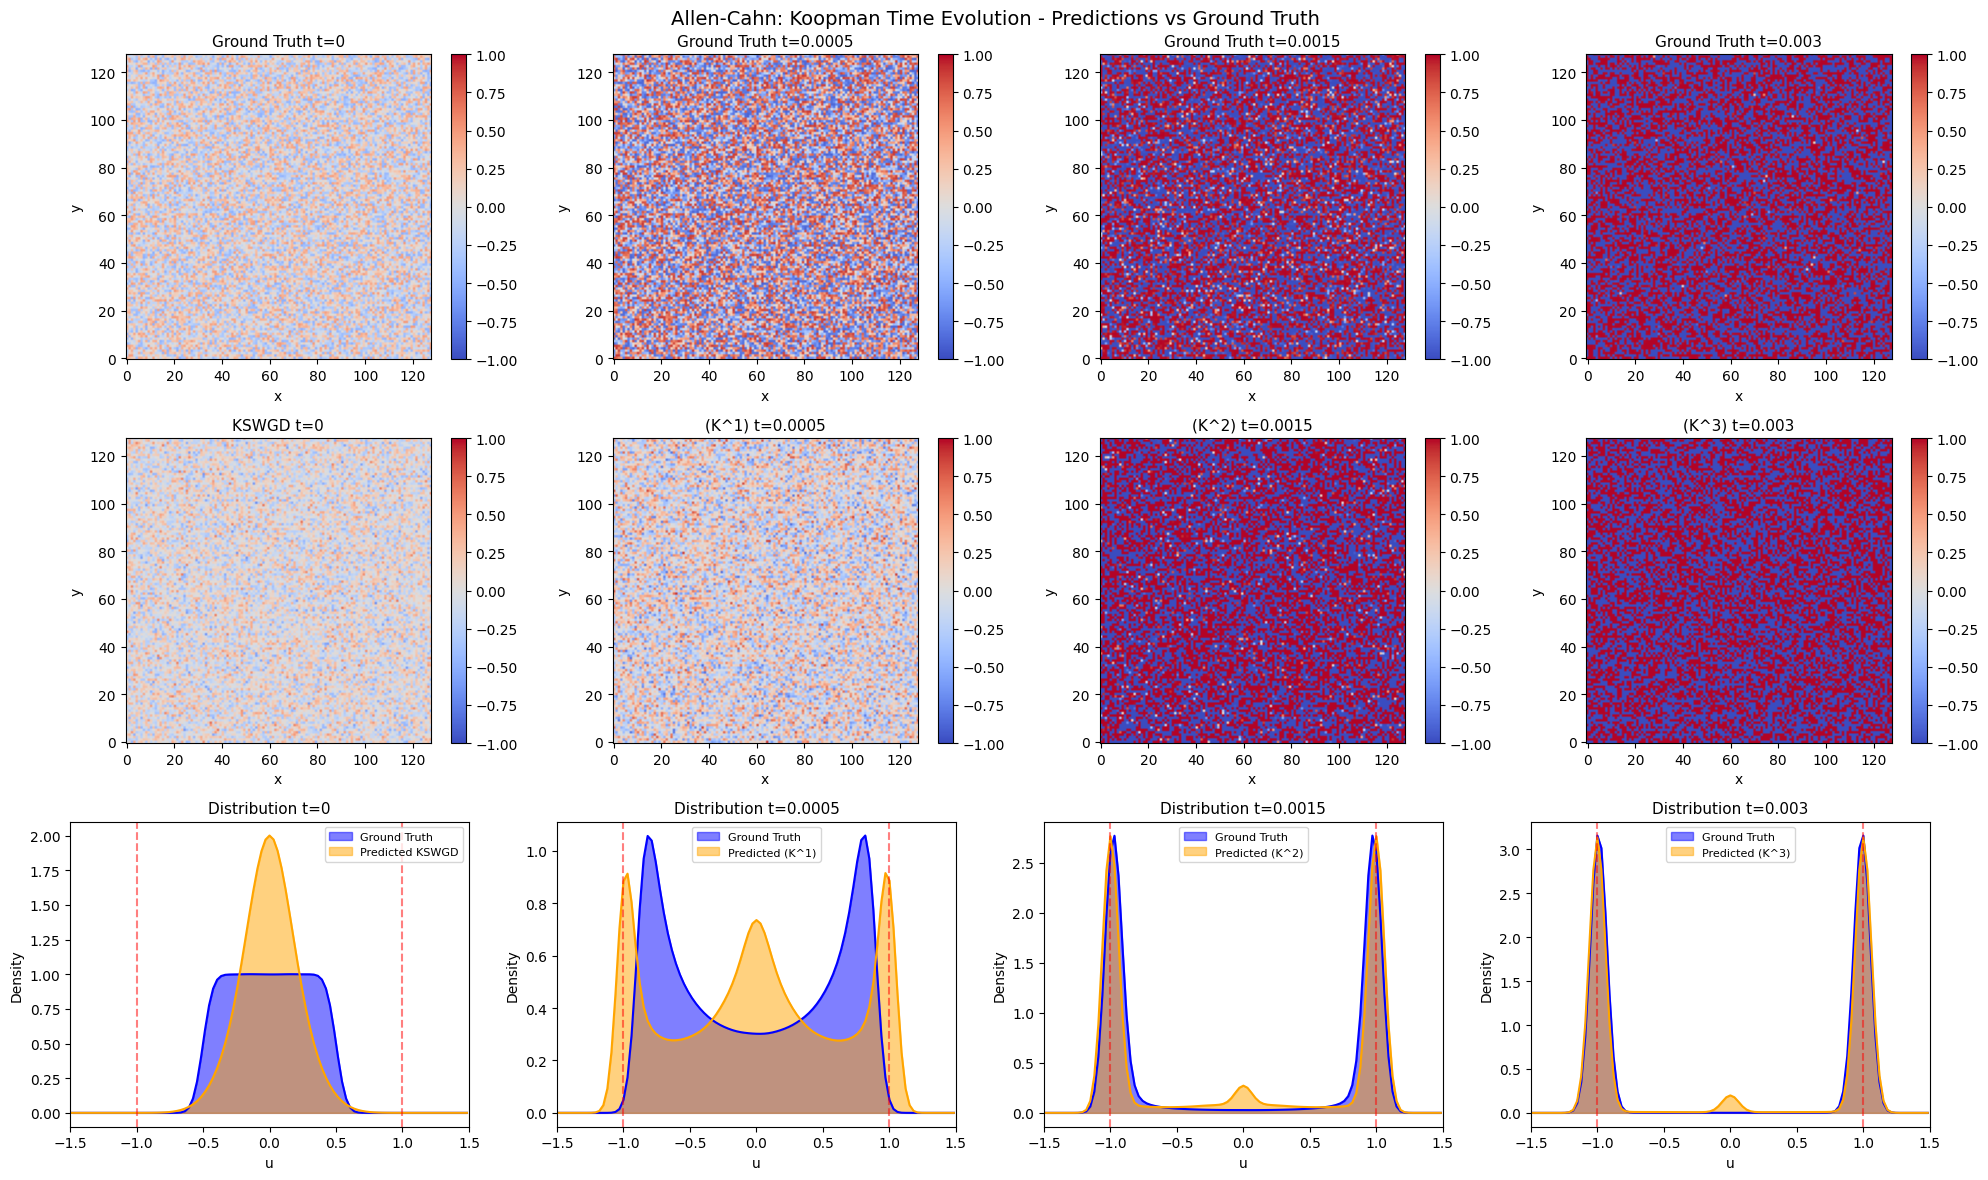


Distribution Statistics: Ground Truth vs Koopman Predictions

t = 0 (KSWGD):
  Ground Truth: mean=0.0001, std=0.2887, near ±1: 0.0%
  Predicted:    mean=0.0001, std=0.2043, near ±1: 0.0%

t = 0.0005 (K^1):
  Ground Truth: mean=0.0002, std=0.6320, near ±1: 25.3%
  Predicted:    mean=0.0000, std=0.6631, near ±1: 36.9%

t = 0.0015 (K^2):
  Ground Truth: mean=0.0002, std=0.9478, near ±1: 92.7%
  Predicted:    mean=-0.0001, std=0.9360, near ±1: 86.2%

t = 0.003 (K^3):
  Ground Truth: mean=-0.0000, std=0.9859, near ±1: 99.8%
  Predicted:    mean=-0.0000, std=0.9789, near ±1: 95.6%


In [7]:
# === Visualization: Koopman Predictions vs Ground Truth ===
from scipy.ndimage import gaussian_filter1d

time_points = kswgd_time_results['meta']['time_points']
n_times = len(time_points)

# Changed from 4 rows to 3 rows (removed latent space row)
fig, axes = plt.subplots(3, n_times, figsize=(5*n_times, 12))

for col, t_phys in enumerate(time_points):
    result = kswgd_time_results[t_phys]
    gt_samples = result['ground_truth_samples']
    pred_samples = result['predicted_samples']
    
    n_koopman = result.get('n_koopman_steps', 0)
    title_suffix = f"(K^{n_koopman})" if n_koopman > 0 else "KSWGD"
    
    # Row 1: Ground Truth Sample
    ax = axes[0, col]
    im = ax.imshow(gt_samples[0], cmap='coolwarm', origin='lower', vmin=-1, vmax=1, interpolation='nearest')
    ax.set_title(f'Ground Truth t={t_phys}', fontsize=11)
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.02)
    
    # Row 2: Koopman Predicted Sample
    ax = axes[1, col]
    im = ax.imshow(pred_samples[0], cmap='coolwarm', origin='lower', vmin=-1, vmax=1, interpolation='nearest')
    ax.set_title(f'{title_suffix} t={t_phys}', fontsize=11)
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.02)
    
    # Row 3: Distribution Comparison using KDE (smoothed)
    ax = axes[2, col]
    gt_values = gt_samples.flatten()
    pred_values = pred_samples.flatten()
    
    # Use histogram with smoothing (Gaussian kernel density estimation approximation)
    bins = np.linspace(-1.5, 1.5, 100)
    bin_centers = (bins[:-1] + bins[1:]) / 2
    
    # Compute histograms
    gt_hist, _ = np.histogram(gt_values, bins=bins, density=True)
    pred_hist, _ = np.histogram(pred_values, bins=bins, density=True)
    
    # Apply Gaussian smoothing to make the distribution smoother
    # This helps visualize the bimodal peaks better
    sigma = 2  # Smoothing parameter
    gt_hist_smooth = gaussian_filter1d(gt_hist, sigma=sigma)
    pred_hist_smooth = gaussian_filter1d(pred_hist, sigma=sigma)
    
    # Plot smoothed distributions
    ax.fill_between(bin_centers, gt_hist_smooth, alpha=0.5, color='blue', label='Ground Truth')
    ax.plot(bin_centers, gt_hist_smooth, color='blue', linewidth=1.5)
    ax.fill_between(bin_centers, pred_hist_smooth, alpha=0.5, color='orange', label=f'Predicted {title_suffix}')
    ax.plot(bin_centers, pred_hist_smooth, color='orange', linewidth=1.5)
    
    ax.set_xlabel('u')
    ax.set_ylabel('Density')
    ax.set_title(f'Distribution t={t_phys}', fontsize=11)
    ax.set_xlim(-1.5, 1.5)
    ax.axvline(x=-1, color='red', linestyle='--', alpha=0.5)
    ax.axvline(x=1, color='red', linestyle='--', alpha=0.5)
    ax.legend(fontsize=8)

plt.suptitle('Allen-Cahn: Koopman Time Evolution - Predictions vs Ground Truth', fontsize=14)
plt.tight_layout(pad=1.1)
plt.show()

# === Distribution Distance Metrics ===
from scipy.stats import wasserstein_distance

def compute_wasserstein_2(p_samples, q_samples):
    """Compute Wasserstein-2 distance for 1D distributions."""
    p_sorted = np.sort(p_samples)
    q_sorted = np.sort(q_samples)
    n = min(len(p_sorted), len(q_sorted))
    p_interp = np.interp(np.linspace(0, 1, n), np.linspace(0, 1, len(p_sorted)), p_sorted)
    q_interp = np.interp(np.linspace(0, 1, n), np.linspace(0, 1, len(q_sorted)), q_sorted)
    w2 = np.sqrt(np.mean((p_interp - q_interp)**2))
    return w2

# Print statistics comparison
print("\n" + "="*70)
print("Distribution Statistics: Ground Truth vs Koopman Predictions")
print("="*70)

for t_phys in time_points:
    result = kswgd_time_results[t_phys]
    gt = result['ground_truth_samples'].flatten()
    pred = result['predicted_samples'].flatten()
    n_koopman = result.get('n_koopman_steps', 0)
    
    # Fraction near ±1 (bimodality measure)
    gt_near_pm1 = np.mean(np.abs(gt) > 0.8)
    pred_near_pm1 = np.mean(np.abs(pred) > 0.8)
    
    method = f"K^{n_koopman}" if n_koopman > 0 else "KSWGD"
    
    print(f"\nt = {t_phys} ({method}):")
    print(f"  Ground Truth: mean={np.mean(gt):.4f}, std={np.std(gt):.4f}, near ±1: {gt_near_pm1:.1%}")
    print(f"  Predicted:    mean={np.mean(pred):.4f}, std={np.std(pred):.4f}, near ±1: {pred_near_pm1:.1%}")

## Baseline Comparison: Diffusion Model & VAE

We compare KSWGD with two popular generative models:
1. **Diffusion Model (DDPM)**: Score-based generative model
2. **VAE (Variational Autoencoder)**: Latent variable model with reconstruction + KL loss

For fair comparison, all methods:
- Use the same training data (ground truth at each time point)
- Generate the same number of samples
- Are evaluated using the same metrics (W1, W2, pixel distribution)

In [8]:
# === Diffusion Model for Allen-Cahn ===
# DDPM-style diffusion model operating in latent space

print("="*70)
print("Training Diffusion Model for Allen-Cahn")
print("="*70)

class DiffusionModel(nn.Module):
    """MLP-based diffusion model for latent space."""
    def __init__(self, latent_dim, hidden_dim=256, time_emb_dim=64):
        super().__init__()
        self.latent_dim = latent_dim
        
        # Time embedding
        self.time_mlp = nn.Sequential(
            nn.Linear(1, time_emb_dim),
            nn.SiLU(),
            nn.Linear(time_emb_dim, time_emb_dim)
        )
        
        # Denoising network
        self.net = nn.Sequential(
            nn.Linear(latent_dim + time_emb_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, latent_dim)
        )
    
    def forward(self, x, t):
        t_emb = self.time_mlp(t.unsqueeze(-1))
        x_t = torch.cat([x, t_emb], dim=-1)
        return self.net(x_t)


class VAELatent(nn.Module):
    """VAE operating in latent space (latent → smaller latent → latent)."""
    def __init__(self, latent_dim, hidden_dim=128, vae_latent_dim=4):
        super().__init__()
        self.vae_latent_dim = vae_latent_dim
        
        # Encoder
        self.encoder = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU()
        )
        self.fc_mu = nn.Linear(hidden_dim, vae_latent_dim)
        self.fc_var = nn.Linear(hidden_dim, vae_latent_dim)
        
        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(vae_latent_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, latent_dim)
        )
    
    def encode(self, x):
        h = self.encoder(x)
        return self.fc_mu(h), self.fc_var(h)
    
    def reparameterize(self, mu, log_var):
        std = torch.exp(0.5 * log_var)
        eps = torch.randn_like(std)
        return mu + eps * std
    
    def decode(self, z):
        return self.decoder(z)
    
    def forward(self, x):
        mu, log_var = self.encode(x)
        z = self.reparameterize(mu, log_var)
        return self.decode(z), mu, log_var


def train_diffusion_and_vae_for_time(time_series_ensemble, target_time, ae, data_min, data_max,
                                      latent_dim=8, n_epochs=150, n_samples_gen=100, verbose=True):
    """
    Train Diffusion Model and VAE for a specific time point.
    
    Args:
        time_series_ensemble: dict of ensembles at each time
        target_time: which time point to train on
        ae: pre-trained autoencoder (from KSWGD)
        data_min, data_max: scaling parameters
        
    Returns:
        dict with diffusion and VAE samples
    """
    data_range = data_max - data_min + 1e-8
    data = time_series_ensemble[target_time]
    n_samples, N, _ = data.shape
    
    # Encode to latent space
    ae.eval()
    data_flat = data.reshape(-1, N*N)
    data_scaled = 2.0 * (data_flat - data_min) / data_range - 1.0
    
    with torch.no_grad():
        tensor = torch.FloatTensor(data_scaled).to(device).view(-1, N, N)
        Z_data = ae.encoder(tensor).cpu().numpy()
    
    # Normalize latent codes for training
    z_mean = Z_data.mean(axis=0)
    z_std = Z_data.std(axis=0) + 1e-8
    Z_norm = (Z_data - z_mean) / z_std
    
    train_tensor = torch.FloatTensor(Z_norm).to(device)
    train_loader = DataLoader(TensorDataset(train_tensor), batch_size=32, shuffle=True)
    
    # ============================================================
    # Train Diffusion Model
    # ============================================================
    if verbose:
        print(f"\n  Training Diffusion Model for t={target_time}...")
    
    n_timesteps = 200
    betas = torch.linspace(1e-4, 0.02, n_timesteps).to(device)
    alphas = 1 - betas
    alphas_cumprod = torch.cumprod(alphas, dim=0)
    
    def q_sample(x0, t, noise=None):
        if noise is None:
            noise = torch.randn_like(x0)
        sqrt_alpha_cumprod = torch.sqrt(alphas_cumprod[t]).unsqueeze(-1)
        sqrt_one_minus = torch.sqrt(1 - alphas_cumprod[t]).unsqueeze(-1)
        return sqrt_alpha_cumprod * x0 + sqrt_one_minus * noise, noise
    
    diffusion = DiffusionModel(latent_dim, hidden_dim=256).to(device)
    optimizer_diff = optim.Adam(diffusion.parameters(), lr=1e-3)
    
    for epoch in range(n_epochs):
        total_loss = 0
        for (batch,) in train_loader:
            optimizer_diff.zero_grad()
            t = torch.randint(0, n_timesteps, (batch.shape[0],)).to(device)
            x_noisy, noise = q_sample(batch, t)
            noise_pred = diffusion(x_noisy, t.float() / n_timesteps)
            loss = nn.MSELoss()(noise_pred, noise)
            loss.backward()
            optimizer_diff.step()
            total_loss += loss.item()
        
        if verbose and (epoch + 1) % 50 == 0:
            print(f"    Epoch {epoch+1}/{n_epochs}, Loss: {total_loss/len(train_loader):.6f}")
    
    # Generate diffusion samples
    @torch.no_grad()
    def sample_diffusion(model, n_samples):
        x = torch.randn(n_samples, latent_dim).to(device)
        for t in reversed(range(n_timesteps)):
            t_batch = torch.full((n_samples,), t, device=device)
            noise_pred = model(x, t_batch.float() / n_timesteps)
            alpha = alphas[t]
            alpha_cumprod_t = alphas_cumprod[t]
            beta = betas[t]
            if t > 0:
                noise = torch.randn_like(x)
            else:
                noise = 0
            x = (1 / torch.sqrt(alpha)) * (x - (beta / torch.sqrt(1 - alpha_cumprod_t)) * noise_pred)
            x = x + torch.sqrt(beta) * noise
        return x
    
    diff_latent_norm = sample_diffusion(diffusion, n_samples_gen).cpu().numpy()
    diff_latent = diff_latent_norm * z_std + z_mean
    
    # ============================================================
    # Train VAE
    # ============================================================
    if verbose:
        print(f"\n  Training VAE for t={target_time}...")
    
    vae = VAELatent(latent_dim, hidden_dim=128, vae_latent_dim=4).to(device)
    optimizer_vae = optim.Adam(vae.parameters(), lr=1e-3)
    
    def vae_loss(recon_x, x, mu, log_var, beta=0.1):
        recon_loss = nn.MSELoss(reduction='sum')(recon_x, x)
        kl_loss = -0.5 * torch.sum(1 + log_var - mu.pow(2) - log_var.exp())
        return recon_loss + beta * kl_loss
    
    for epoch in range(n_epochs):
        total_loss = 0
        for (batch,) in train_loader:
            optimizer_vae.zero_grad()
            recon, mu, log_var = vae(batch)
            loss = vae_loss(recon, batch, mu, log_var, beta=0.1)
            loss.backward()
            optimizer_vae.step()
            total_loss += loss.item()
        
        if verbose and (epoch + 1) % 50 == 0:
            print(f"    Epoch {epoch+1}/{n_epochs}, Loss: {total_loss/len(train_tensor):.4f}")
    
    # Generate VAE samples
    @torch.no_grad()
    def sample_vae(model, n_samples):
        z = torch.randn(n_samples, model.vae_latent_dim).to(device)
        return model.decode(z)
    
    vae_latent_norm = sample_vae(vae, n_samples_gen).cpu().numpy()
    vae_latent = vae_latent_norm * z_std + z_mean
    
    # ============================================================
    # Decode both to original space
    # ============================================================
    def decode_latent(z_latent):
        with torch.no_grad():
            z_tensor = torch.FloatTensor(z_latent).to(device)
            decoded = ae.decoder(z_tensor).cpu().numpy()
        samples = (decoded.reshape(-1, N*N) + 1.0) / 2.0 * data_range + data_min
        return samples.reshape(-1, N, N)
    
    diff_samples = decode_latent(diff_latent)
    vae_samples = decode_latent(vae_latent)
    
    return {
        'diffusion_samples': diff_samples,
        'diffusion_latent': diff_latent,
        'vae_samples': vae_samples,
        'vae_latent': vae_latent,
        'ground_truth': data,
    }


# Train Diffusion and VAE for each time point
print("\nTraining baseline models for each time point...")

# Get autoencoder and scaling from KSWGD results
ae = kswgd_time_results['meta']['ae']
# Need to get data_min and data_max - recompute from ensemble
all_data = np.concatenate([time_series_ensemble[t] for t in time_points], axis=0)
data_min = all_data.min()
data_max = all_data.max()

baseline_results = {}
for t_target in time_points:
    print(f"\n{'='*60}")
    print(f"Time t = {t_target}")
    print(f"{'='*60}")
    
    result = train_diffusion_and_vae_for_time(
        time_series_ensemble,
        target_time=t_target,
        ae=ae,
        data_min=data_min,
        data_max=data_max,
        latent_dim=8,
        n_epochs=150,
        n_samples_gen=100,
        verbose=True
    )
    baseline_results[t_target] = result

print("\n" + "="*70)
print("Baseline model training complete!")
print("="*70)

Training Diffusion Model for Allen-Cahn

Training baseline models for each time point...

Time t = 0

  Training Diffusion Model for t=0...
    Epoch 50/150, Loss: 0.654837
    Epoch 100/150, Loss: 0.622499
    Epoch 150/150, Loss: 0.581522

  Training VAE for t=0...
    Epoch 50/150, Loss: 3.3961
    Epoch 100/150, Loss: 2.5752
    Epoch 150/150, Loss: 2.0961

Time t = 0.0005

  Training Diffusion Model for t=0.0005...
    Epoch 50/150, Loss: 0.641651
    Epoch 100/150, Loss: 0.586785
    Epoch 150/150, Loss: 0.615453

  Training VAE for t=0.0005...
    Epoch 50/150, Loss: 3.3810
    Epoch 100/150, Loss: 2.5228
    Epoch 150/150, Loss: 2.0795

Time t = 0.0015

  Training Diffusion Model for t=0.0015...
    Epoch 50/150, Loss: 0.576814
    Epoch 100/150, Loss: 0.564855
    Epoch 150/150, Loss: 0.616549

  Training VAE for t=0.0015...
    Epoch 50/150, Loss: 3.3748
    Epoch 100/150, Loss: 2.6011
    Epoch 150/150, Loss: 2.1610

Time t = 0.003

  Training Diffusion Model for t=0.003...


FINAL COMPARISON: KSWGD vs Diffusion vs VAE


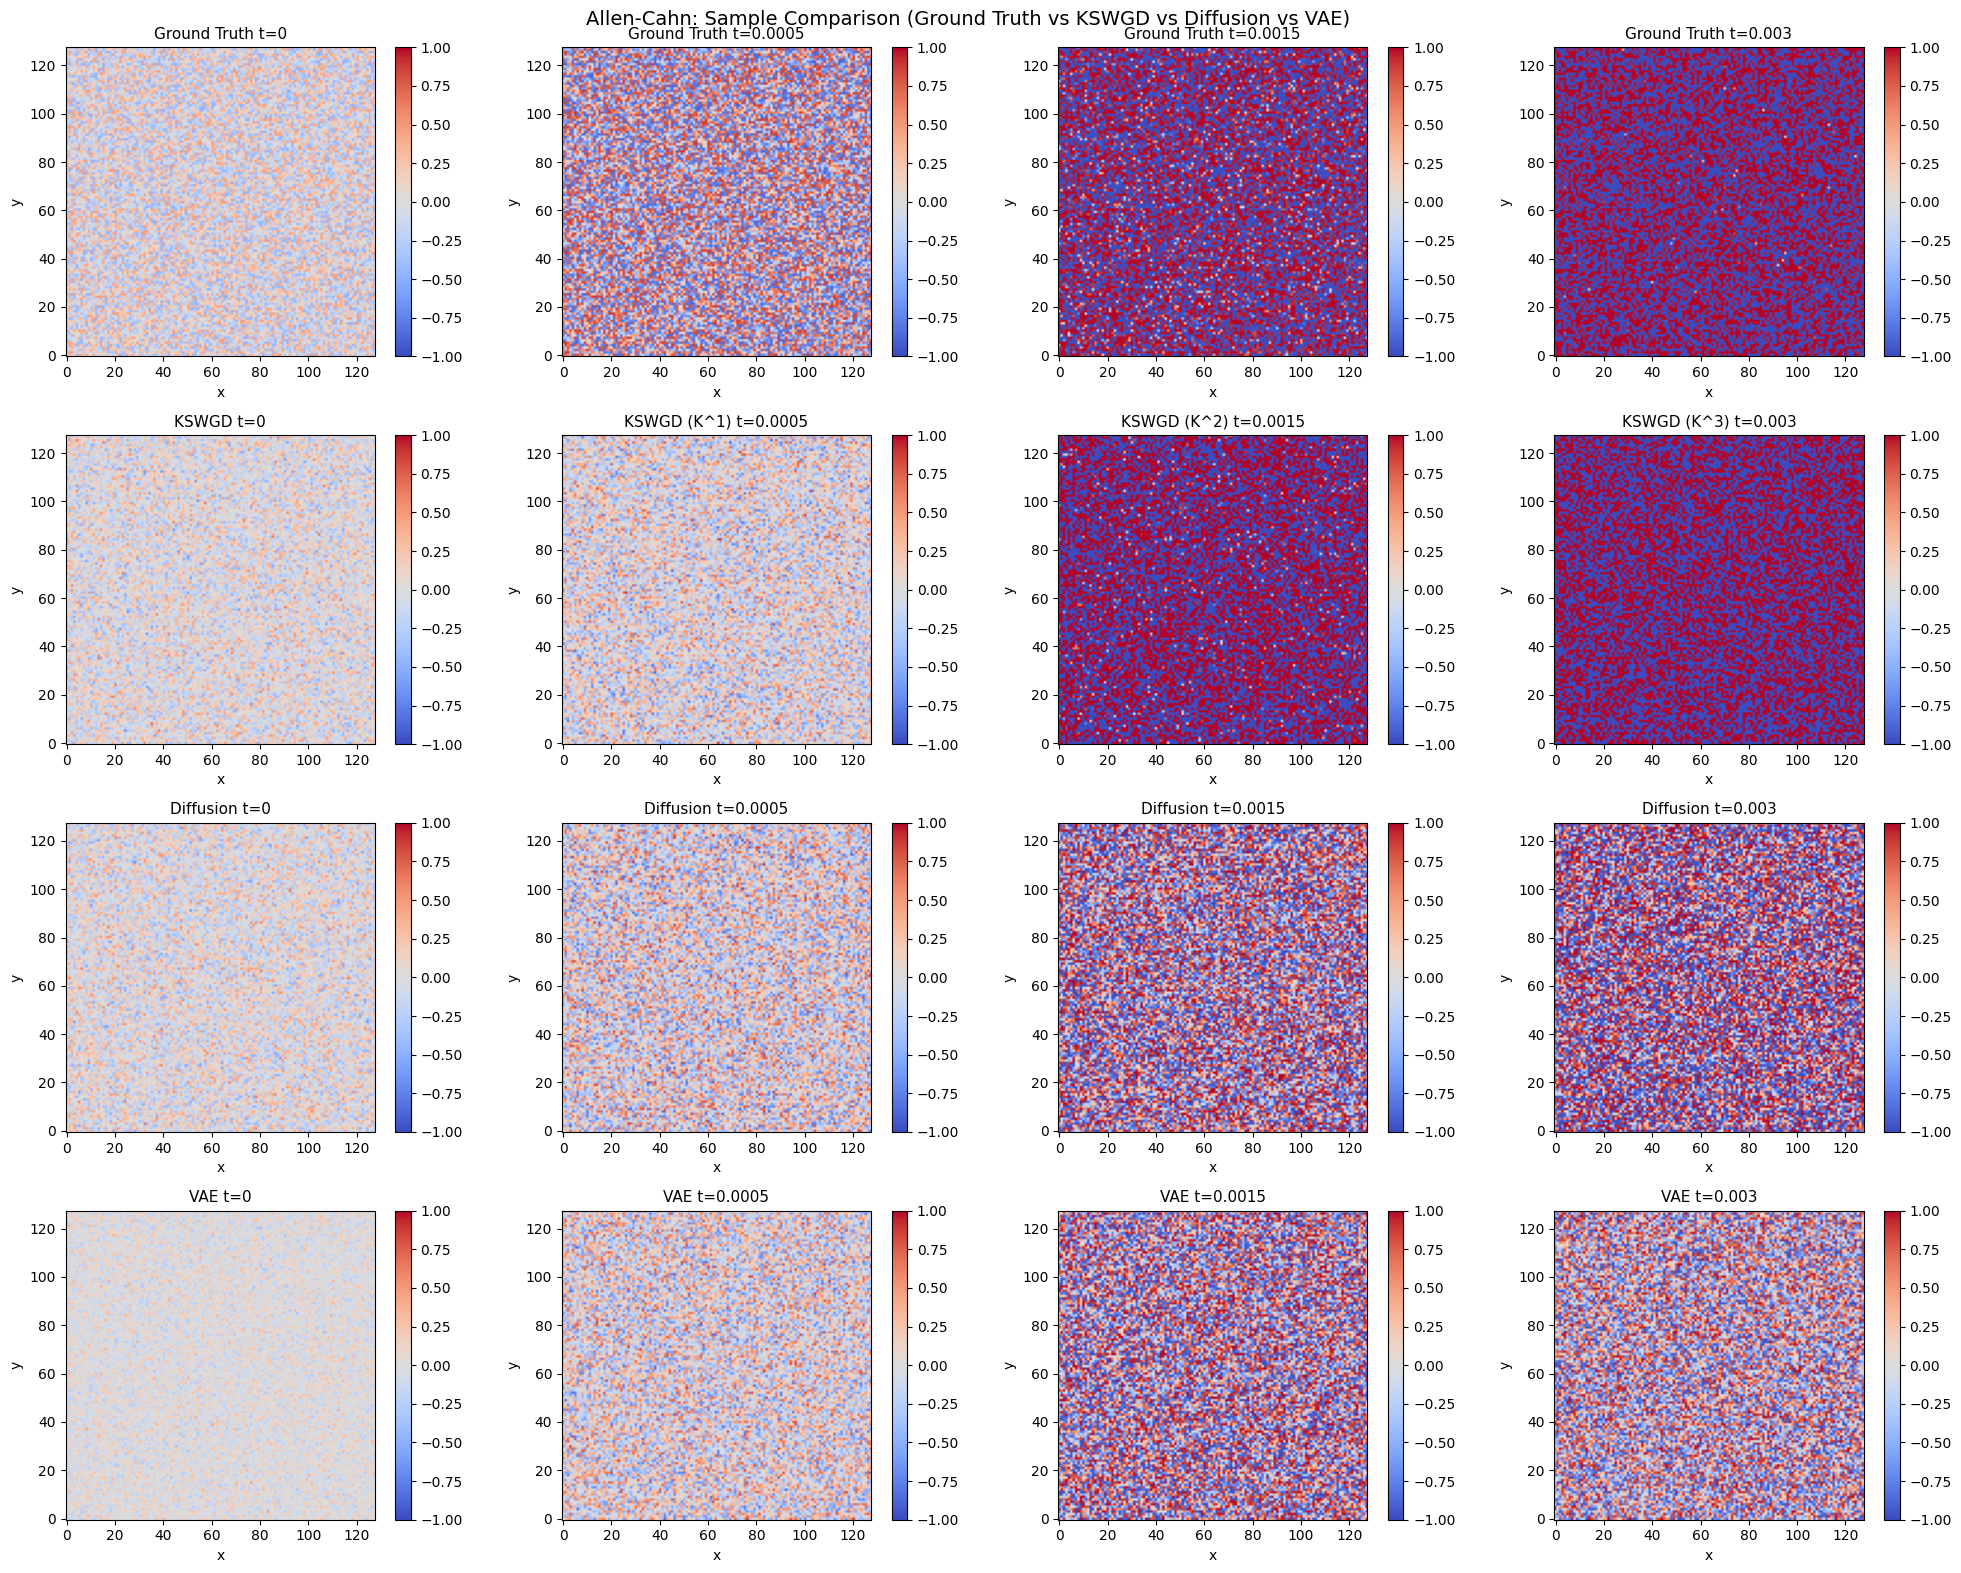

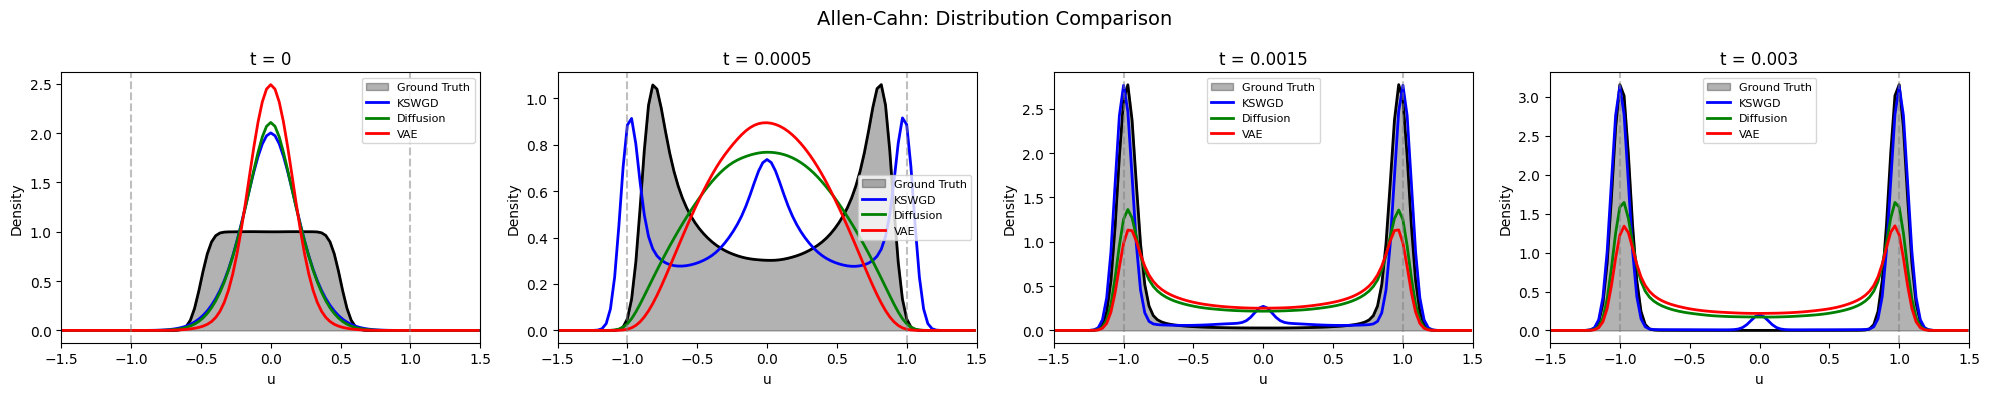

In [9]:
# === Final Comparison: KSWGD vs Diffusion vs VAE ===
from scipy.ndimage import gaussian_filter1d
from scipy.stats import wasserstein_distance

print("="*70)
print("FINAL COMPARISON: KSWGD vs Diffusion vs VAE")
print("="*70)

n_times = len(time_points)

# Create comparison figure
fig, axes = plt.subplots(4, n_times, figsize=(5*n_times, 16))

for col, t_phys in enumerate(time_points):
    # Get all results
    kswgd_result = kswgd_time_results[t_phys]
    baseline_result = baseline_results[t_phys]
    
    gt_samples = kswgd_result['ground_truth_samples']
    kswgd_samples = kswgd_result['predicted_samples']
    diff_samples = baseline_result['diffusion_samples']
    vae_samples = baseline_result['vae_samples']
    
    n_koopman = kswgd_result.get('n_koopman_steps', 0)
    kswgd_label = f"KSWGD (K^{n_koopman})" if n_koopman > 0 else "KSWGD"
    
    # Row 1: Ground Truth Sample
    ax = axes[0, col]
    im = ax.imshow(gt_samples[0], cmap='coolwarm', origin='lower', vmin=-1, vmax=1, interpolation='nearest')
    ax.set_title(f'Ground Truth t={t_phys}', fontsize=11)
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.02)
    
    # Row 2: KSWGD Sample
    ax = axes[1, col]
    im = ax.imshow(kswgd_samples[0], cmap='coolwarm', origin='lower', vmin=-1, vmax=1, interpolation='nearest')
    ax.set_title(f'{kswgd_label} t={t_phys}', fontsize=11)
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.02)
    
    # Row 3: Diffusion Sample
    ax = axes[2, col]
    im = ax.imshow(diff_samples[0], cmap='coolwarm', origin='lower', vmin=-1, vmax=1, interpolation='nearest')
    ax.set_title(f'Diffusion t={t_phys}', fontsize=11)
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.02)
    
    # Row 4: VAE Sample
    ax = axes[3, col]
    im = ax.imshow(vae_samples[0], cmap='coolwarm', origin='lower', vmin=-1, vmax=1, interpolation='nearest')
    ax.set_title(f'VAE t={t_phys}', fontsize=11)
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.02)

plt.suptitle('Allen-Cahn: Sample Comparison (Ground Truth vs KSWGD vs Diffusion vs VAE)', fontsize=14)
plt.tight_layout(pad=1.1)
plt.show()

# === Distribution Comparison Figure ===
fig2, axes2 = plt.subplots(1, n_times, figsize=(5*n_times, 4))

for col, t_phys in enumerate(time_points):
    kswgd_result = kswgd_time_results[t_phys]
    baseline_result = baseline_results[t_phys]
    
    gt_values = kswgd_result['ground_truth_samples'].flatten()
    kswgd_values = kswgd_result['predicted_samples'].flatten()
    diff_values = baseline_result['diffusion_samples'].flatten()
    vae_values = baseline_result['vae_samples'].flatten()
    
    ax = axes2[col]
    
    # Compute smoothed histograms
    bins = np.linspace(-1.5, 1.5, 100)
    bin_centers = (bins[:-1] + bins[1:]) / 2
    sigma = 2
    
    gt_hist, _ = np.histogram(gt_values, bins=bins, density=True)
    kswgd_hist, _ = np.histogram(kswgd_values, bins=bins, density=True)
    diff_hist, _ = np.histogram(diff_values, bins=bins, density=True)
    vae_hist, _ = np.histogram(vae_values, bins=bins, density=True)
    
    gt_smooth = gaussian_filter1d(gt_hist, sigma=sigma)
    kswgd_smooth = gaussian_filter1d(kswgd_hist, sigma=sigma)
    diff_smooth = gaussian_filter1d(diff_hist, sigma=sigma)
    vae_smooth = gaussian_filter1d(vae_hist, sigma=sigma)
    
    # Plot
    ax.fill_between(bin_centers, gt_smooth, alpha=0.3, color='black', label='Ground Truth')
    ax.plot(bin_centers, gt_smooth, color='black', linewidth=2)
    ax.plot(bin_centers, kswgd_smooth, color='blue', linewidth=2, label='KSWGD')
    ax.plot(bin_centers, diff_smooth, color='green', linewidth=2, label='Diffusion')
    ax.plot(bin_centers, vae_smooth, color='red', linewidth=2, label='VAE')
    
    ax.set_xlabel('u')
    ax.set_ylabel('Density')
    ax.set_title(f't = {t_phys}', fontsize=12)
    ax.set_xlim(-1.5, 1.5)
    ax.axvline(x=-1, color='gray', linestyle='--', alpha=0.5)
    ax.axvline(x=1, color='gray', linestyle='--', alpha=0.5)
    ax.legend(fontsize=8)

plt.suptitle('Allen-Cahn: Distribution Comparison', fontsize=14)
plt.tight_layout(pad=1.1)
plt.show()